# scimilarity Embedding Inspection and UMAP Visualization

Author: Yuxuan Xu

Description:
This script inspects and visualizes scimilarity embeddings derived from
single-cell data. It focuses on understanding the structure of the
embedding space and evaluating its biological and technical signals.

Main steps:
- Check embedding and UMAP dimensions
- Inspect numerical values of the embedding matrix
- Visualize UMAP colored by metadata (e.g. batch, cell type, development stage)
- Generate diagnostic plots for assessing embedding quality

Goals:
- Evaluate batch mixing across samples
- Assess global cell type structure
- Examine developmental (lineage) organization

Inputs:
- AnnData object with:
    - Embeddings: adata.obsm['X_emb--metrics:scimilarity']
    - UMAP: adata.obsm['X_umap--metrics:scimilarity']
    - Metadata in adata.obs

Outputs:
- UMAP visualization plots (PDF)
- Diagnostic figures for embedding evaluation

Notes:
- Side-by-side visualization enables comparison across biological signals
- Useful for qualitative assessment of representation quality

In [2]:
import scanpy as sc
import anndata as ad

/home/ubuntu/miniforge/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
!pip install colorcet

In [4]:
adata = ad.read_zarr("/vol/data/data/output/HRCA/RGC.zarr")

In [5]:
print(adata.obsm.keys())

KeysView(AxisArrays with keys: X_emb--metrics:drvi_global, X_emb--metrics:drvi_lineage, X_emb--metrics:harmony_global, X_emb--metrics:harmony_lineage, X_emb--metrics:scpoli_global, X_emb--metrics:scpoli_lineage, X_emb--metrics:scvi_global, X_emb--metrics:scvi_lineage, X_umap--metrics:drvi_global, X_umap--metrics:drvi_lineage, X_umap--metrics:harmony_global, X_umap--metrics:harmony_lineage, X_umap--metrics:scpoli_global, X_umap--metrics:scpoli_lineage, X_umap--metrics:scvi_global, X_umap--metrics:scvi_lineage)


In [6]:
print(adata.obs.columns.tolist())

['reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'sex_ontology_term_id', 'majorclass', 'AC_subclass', 'AC_cluster', 'AC_celltype_number', 'BC_subclass', 'RGC_cluster', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA',

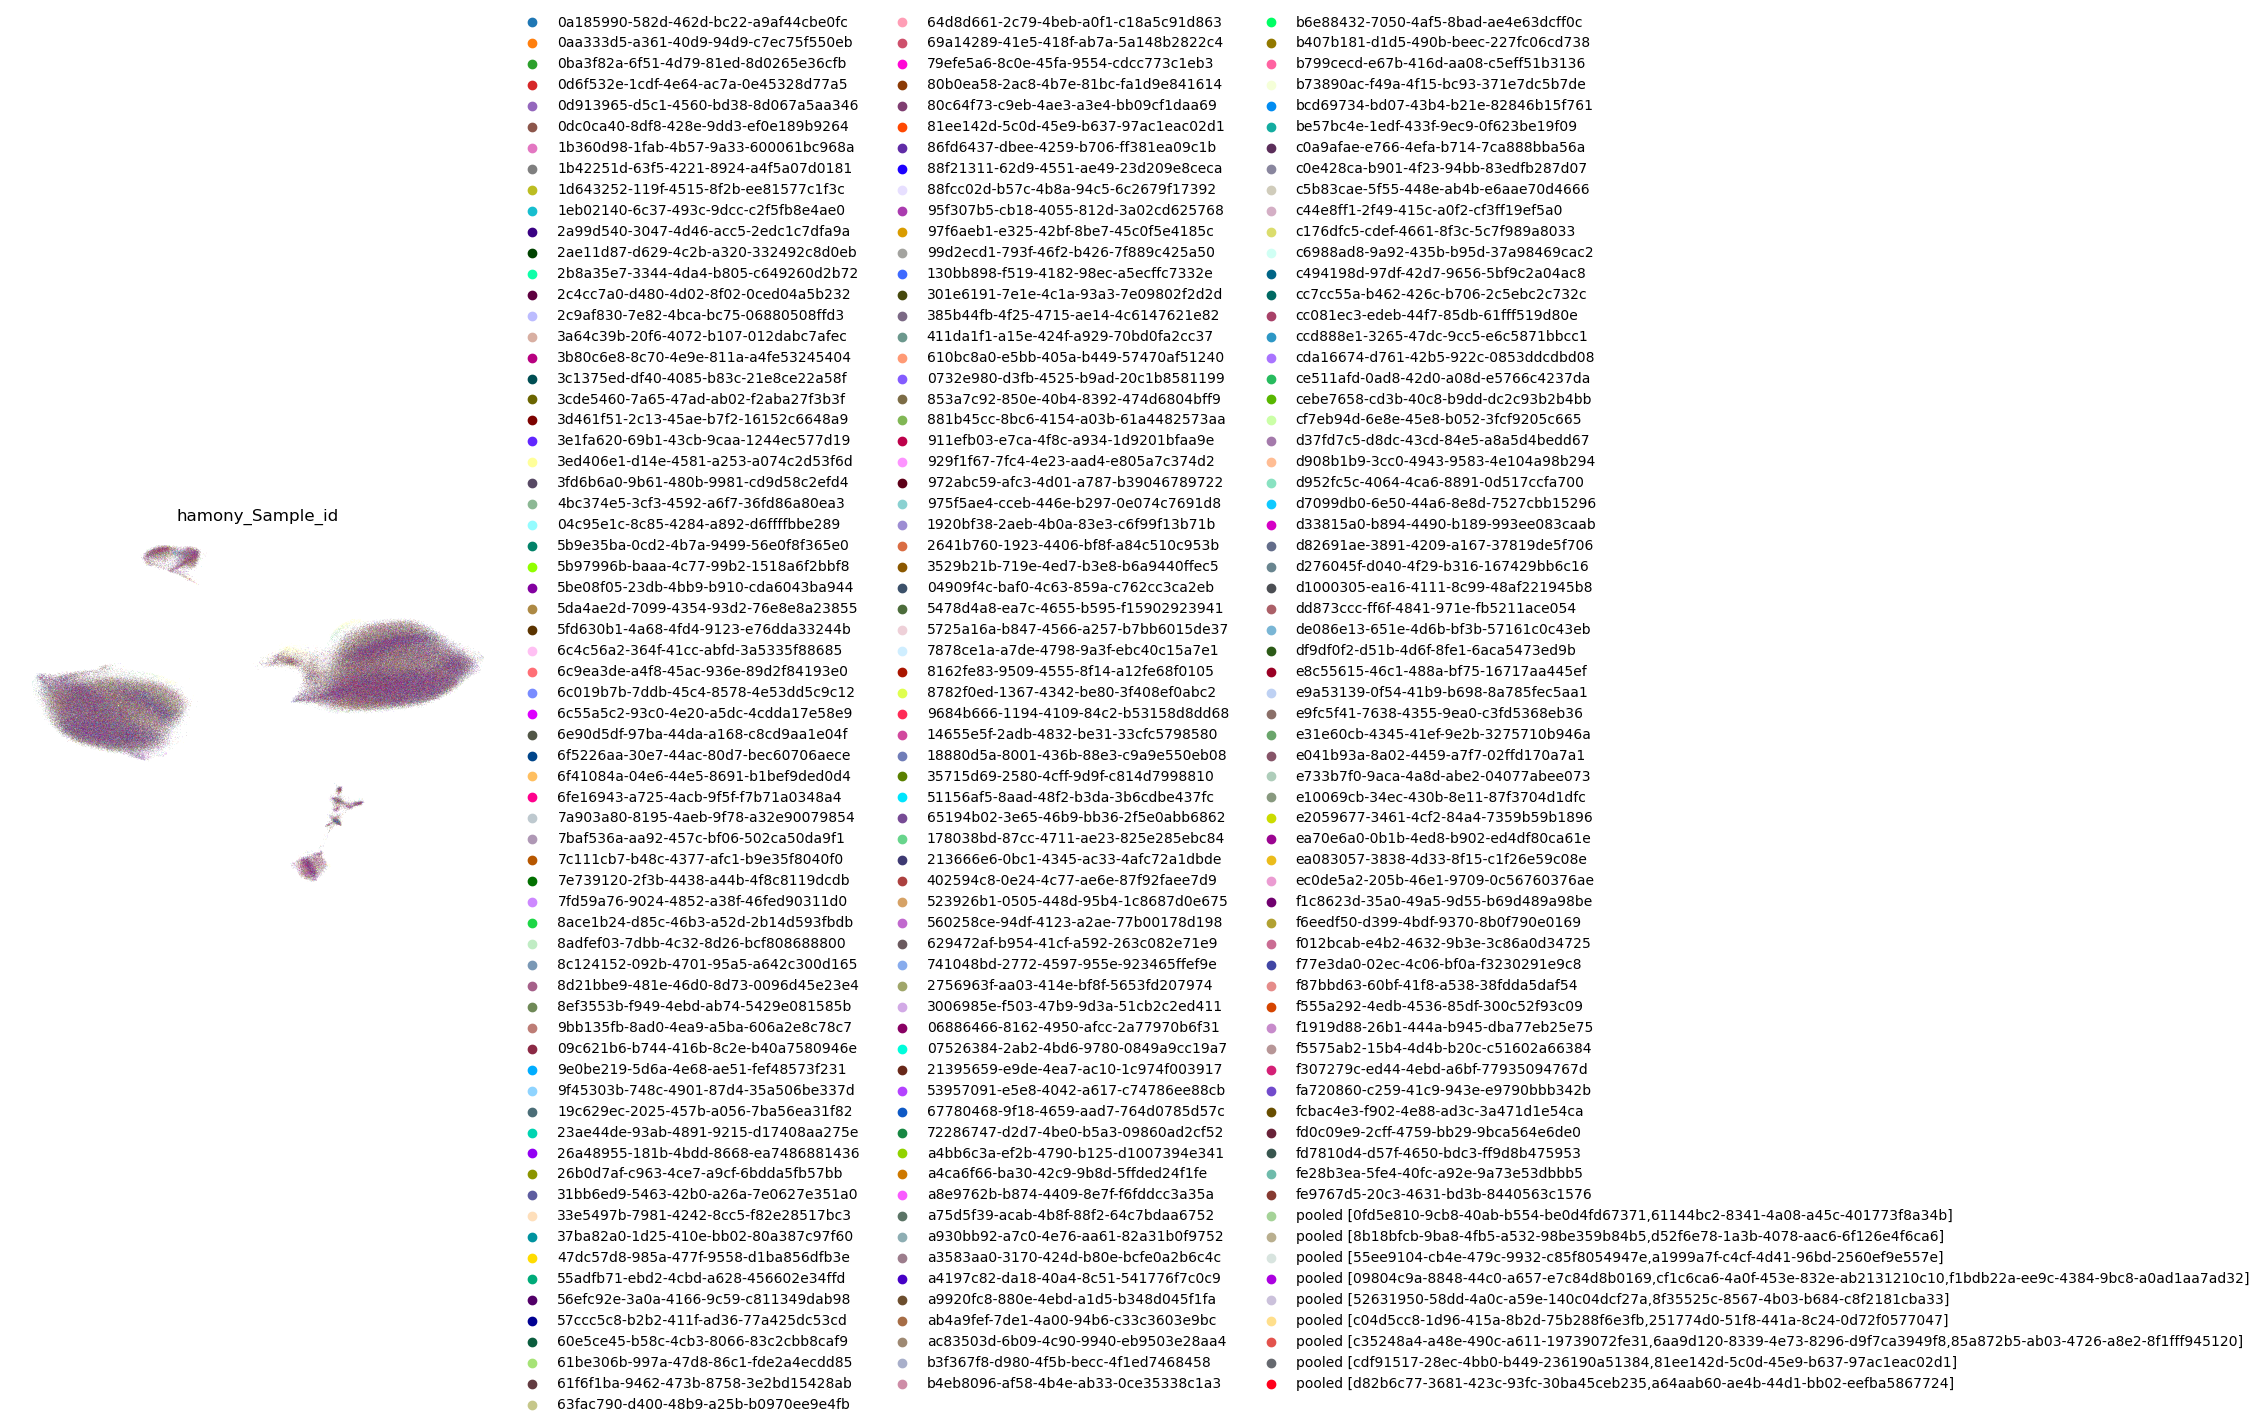

In [11]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap--metrics:harmony_lineage", 
    color=["sample_id"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["hamony_Sample_id"],
    save = "_RGC_results_sampleid.png"
)

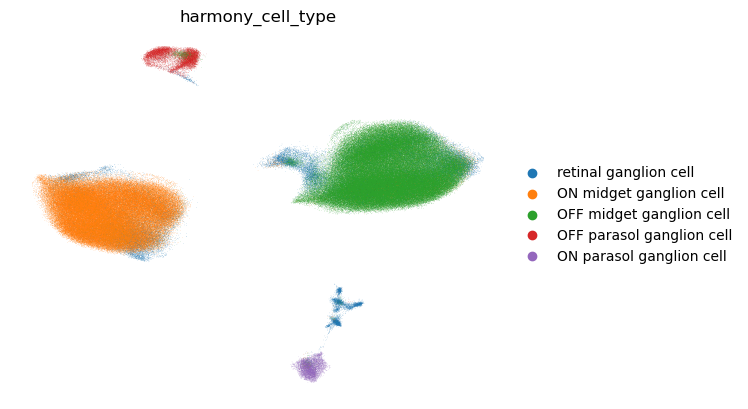

In [8]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap--metrics:harmony_lineage", 
    color=["cell_type"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["harmony_cell_type"],
    save = "_RGC_results_harmony_celltype.pdf"
)

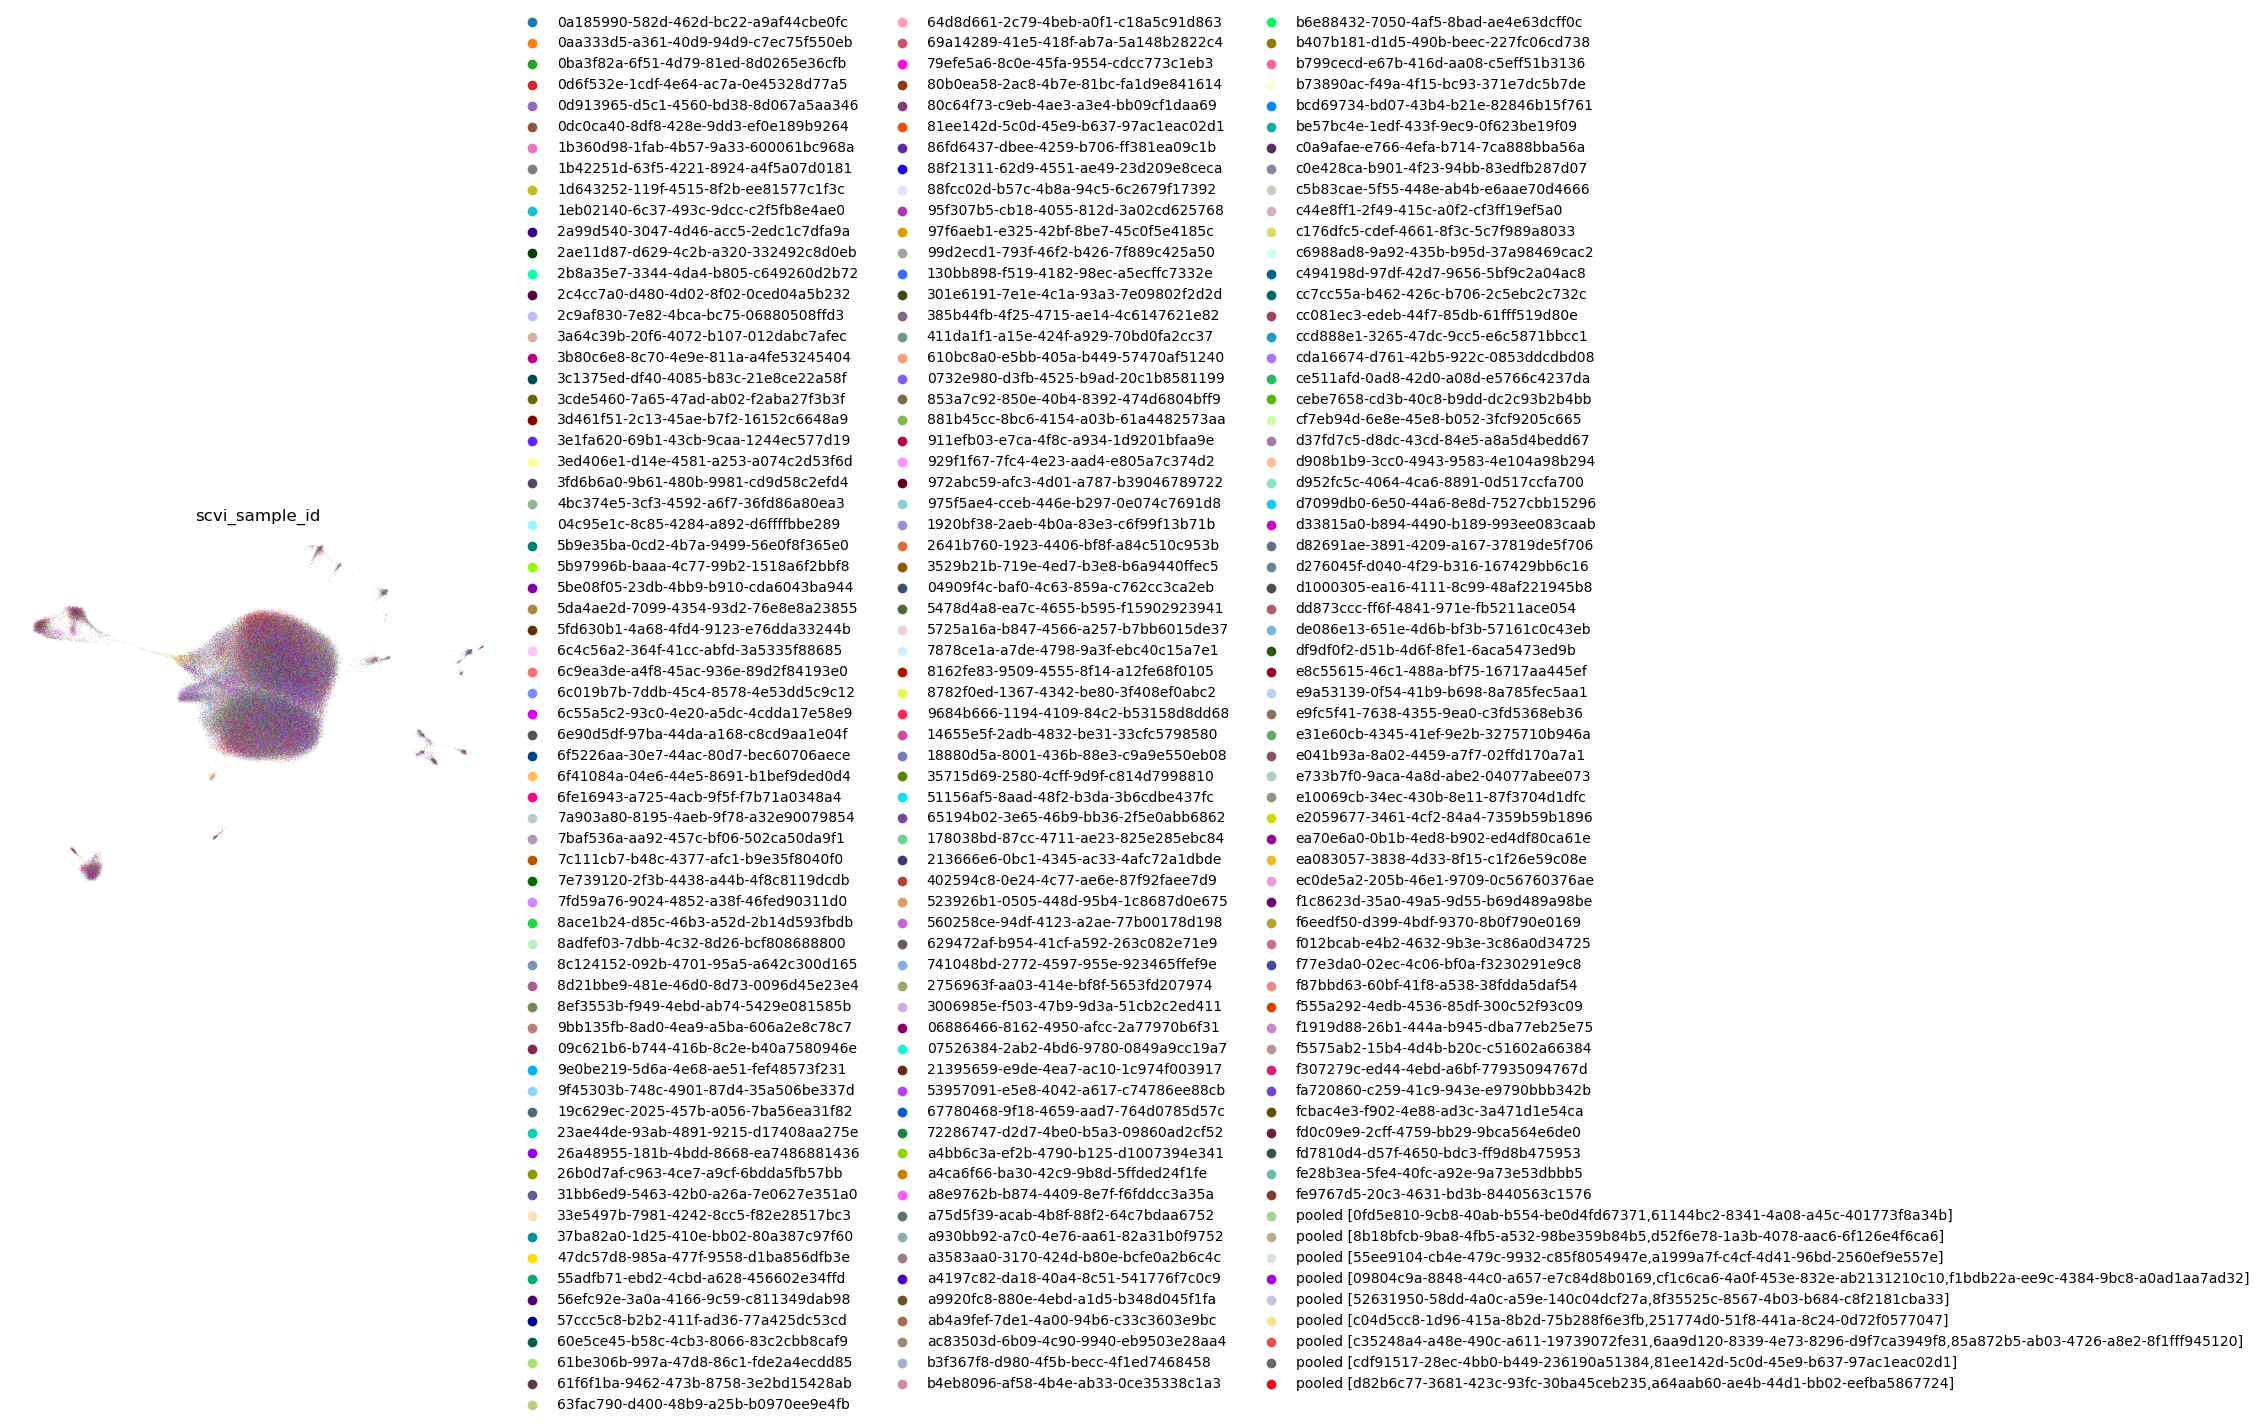

In [9]:
sc.pl.embedding(
    adata, 
    basis="X_umap--metrics:scvi_lineage", 
    color=["sample_id"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["scvi_sample_id"],
    save = "_RGC_results_harmony1_celltype.pdf"
)

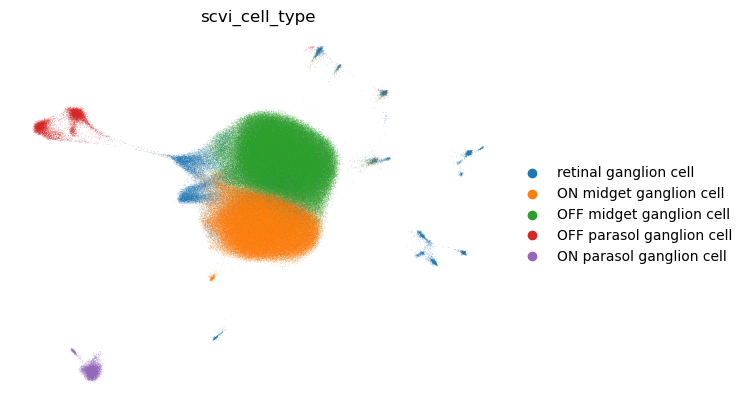

In [10]:
import colorcet as cc
palette_extended = cc.cm.glasbey_category10.colors
sc.pl.embedding(
    adata, 
    basis="X_umap--metrics:scvi_lineage", 
    color=["cell_type"], 
    ncols=1,
    palette=list(palette_extended),
    frameon=False,
    title=["scvi_cell_type"],
    save = "_RGC_results_harmony2_celltype.pdf"
)